# Task 4.3 — Single Strain HAI Vic B/Austria/1359417/2021 (D28)

**4.3 predict magnitude of antibody response - Vic B/Austria/1359417/2021 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for Vic B/Austria/1359417/2021 at Day 28

---

## Design notes

**y-values:** log2-transformed. Since Spearman only cares about ranking, no inverse transform is needed for evaluation. Metrics (RMSE, MAE, Spearman) are all in log2 space; CSVs use `np.exp2` to output raw titer scale values.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale. Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
STRAIN = 'Vic B/Austria/1359417/2021'
TARGET_COL = f'HAI_{STRAIN}_d28'
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [3]:
import io
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — target coverage

Only ~920 / 3757 participants have `HAI_Vic B/Austria/1359417/2021_d28`. Two options:
1. **Drop rows without the target** (current approach below) — clean but discards ~75% of the data.
2. **TODO: Borrow from similar strains.** Other Vic B strains (e.g. earlier B/Victoria lineage strains in the same dataset) may carry signal. Could either (a) impute the target from a correlated strain, or (b) train a multi-target model and only score on this strain. Defer until we have a baseline.

In [5]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Pre-filtered shape: {df.shape}')

Pre-filtered shape: (3757, 110063)


In [6]:
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Filtered shape: {df.shape}')

Filtered shape: (920, 110063)


In [7]:
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns. New shape: {df.shape}')

Dropped 82072 all-null columns. New shape: (920, 27991)


In [8]:
print(f'Shape: {df.shape}')
print(f'Target stats (log2):\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')
print(f'\nMissing per column (top 10):\n{df.isna().sum().sort_values(ascending=False).head(10)}')

Shape: (920, 27991)
Target stats (log2):
count    920.000000
mean       4.956711
std        2.137109
min        2.321928
25%        3.321928
50%        5.321928
75%        6.321928
max       12.321928
Name: HAI_Vic B/Austria/1359417/2021_d28, dtype: float64

dtype counts:
float64    27986
str            5
Name: count, dtype: int64

Missing per column (top 10):
TRAN_ENSG00000181001_d0    872
TRAN_ENSG00000228549_d0    872
TRAN_ENSG00000228594_d0    872
TRAN_ENSG00000228590_d0    872
TRAN_ENSG00000228587_d0    872
TRAN_ENSG00000228577_d0    872
TRAN_ENSG00000228573_d0    872
TRAN_ENSG00000228570_d0    872
TRAN_ENSG00000228567_d0    872
TRAN_ENSG00000228566_d0    872
dtype: int64


---
## AutoML Setup

In [9]:
# abcdefg  # supposed to make the notebook stop

In [10]:
warnings.filterwarnings("ignore", category=UserWarning, module="h2o")
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "24.0.1" 2025-04-15; OpenJDK Runtime Environment Homebrew (build 24.0.1); OpenJDK 64-Bit Server VM Homebrew (build 24.0.1, mixed mode, sharing)
  Starting server from /Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpilaeriln
  JVM stdout: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpilaeriln/h2o_chayan_started_from_python.out
  JVM stderr: /var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/tmpilaeriln/h2o_chayan_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 21 days
H2O_cluster_name:,H2O_from_python_chayan_b52tyx
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,15.98 Gb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


In [11]:
data = h2o.H2OFrame(df)
print(f'H2OFrame shape: {data.shape}')

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (920, 27991)


---
## AutoML Training

In [12]:
# Features: everything available at d0 + d7 — exclude all d28/d365 targets and participant_id
x = [c for c in data.columns
     if not c.endswith('_d28') and not c.endswith('_d365')
     and c != 'participant_id']
y = TARGET_COL

train = data[data[y].isna() == 0]
print(f'Training samples: {train.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=train)
print('Training complete.')

Training samples: 920  |  Features: 27958
Training complete.


In [13]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                           rmse      mse      mae     rmsle    mean_residual_deviance
GLM_1_AutoML_1_20260503_164916  2.13595  4.56227  1.78958  0.373444                   4.56227
[1 row x 6 columns]



In [14]:
cv_preds = aml.leader.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = train[y].as_data_frame()[y]
rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.3 — Spearman (5-fold CV): {rho:.3f}  (p={pval:.4f})')

Task 4.3 — Spearman (5-fold CV): nan  (p=nan)


/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/Users/chayan/anaconda3/envs/cmi-flu-prediction-challenge-capstone/lib/python3.13/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/var/folders/kp/4mhl7j_j6354gqcs12nt1y680000gn/T/ipykernel_11538/1714758134.py:3: ConstantInputWarning

Leader model: GLM_1_AutoML_1_20260503_164916


,variable,relative_importance,scaled_importance,percentage
0,HAI_H1N1 A/Victoria/4897/2022_d0.2.32192809488...,0.0,NaN,NaN
1,HAI_H1N1 A/Victoria/4897/2022_d0.3.32192809488...,0.0,NaN,NaN
2,HAI_H1N1 A/Victoria/4897/2022_d0.4.32192809488...,0.0,NaN,NaN
3,HAI_H1N1 A/Victoria/4897/2022_d0.5.32192809488...,0.0,NaN,NaN
4,HAI_H1N1 A/Victoria/4897/2022_d0.6.32192809488...,0.0,NaN,NaN
5,HAI_H1N1 A/Victoria/4897/2022_d0.7.32192809488...,0.0,NaN,NaN
6,HAI_H1N1 A/Victoria/4897/2022_d0.nan,0.0,NaN,NaN
7,PART_arm_name.High Dose Fluzone,0.0,NaN,NaN
8,PART_arm_name.Standard Fluzone,0.0,NaN,NaN
9,PART_biological_sex.Female,0.0,NaN,NaN


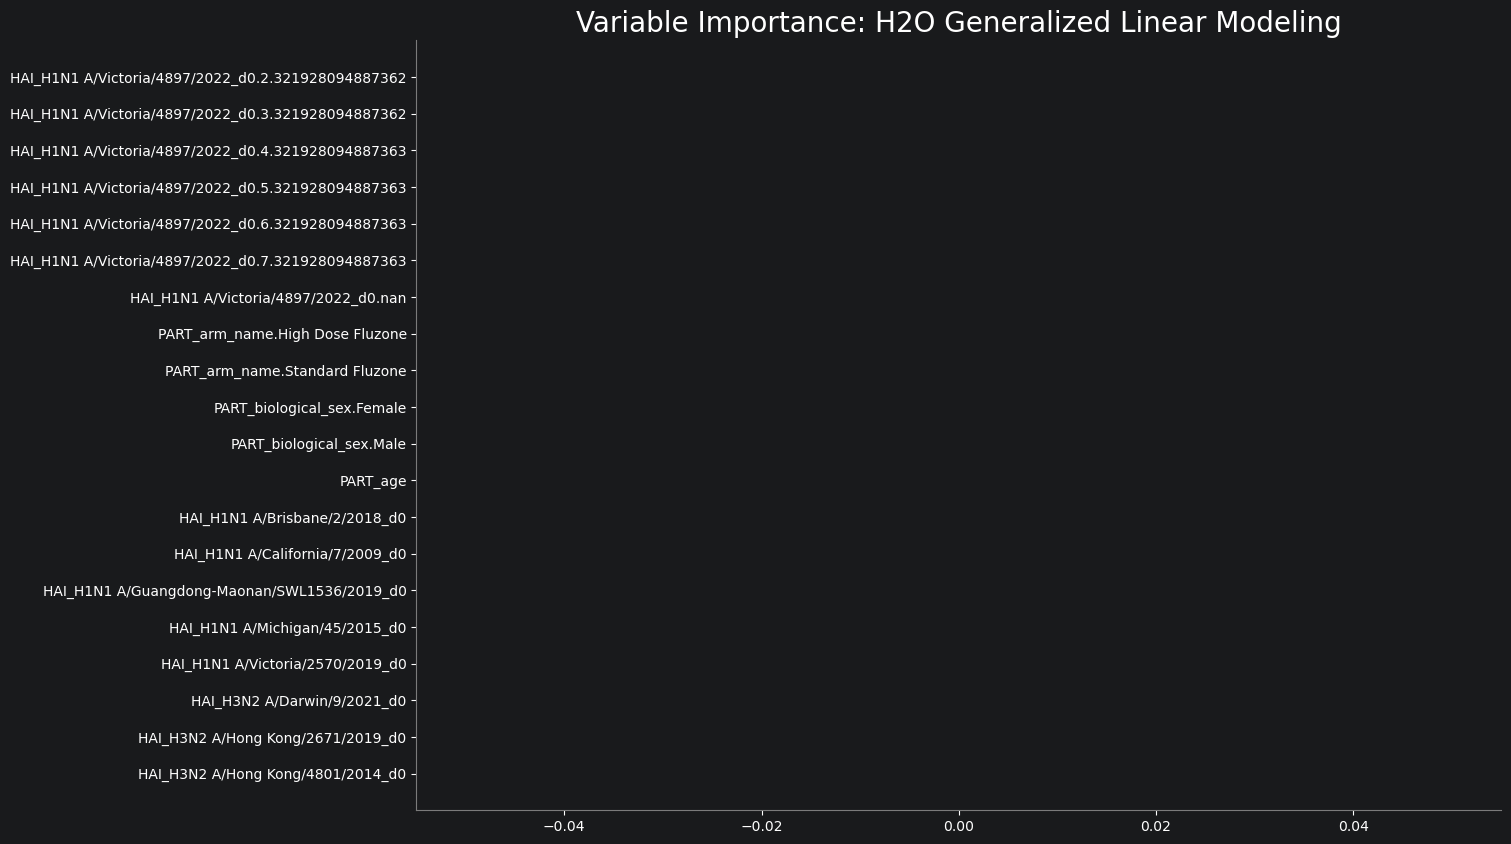

<Figure size 640x480 with 0 Axes>

In [15]:
print(f'Leader model: {aml.leader.model_id}')
varimp = aml.leader.varimp(use_pandas=True)
display(varimp.head(20))
aml.leader.varimp_plot(num_of_features=20)

In [16]:
challenge_hf = h2o.H2OFrame(challenge_data)
y_pred = aml.leader.predict(challenge_hf).as_data_frame()['predict']

results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.3': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_3.csv', index=False)
results

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: | (failed)


OSError: Job with key $03017f00000132d4ffffffff$_a6dbffe3569fc8a6d319e7bae7b4427a failed with an exception: java.lang.IllegalArgumentException: Test/Validation dataset has a non-categorical column 'HAI_H1N1 A/Victoria/4897/2022_d0' which is categorical in the training data
stacktrace: 
java.lang.IllegalArgumentException: Test/Validation dataset has a non-categorical column 'HAI_H1N1 A/Victoria/4897/2022_d0' which is categorical in the training data
	at hex.Model.adaptTestForTrain(Model.java:1820)
	at hex.Model.adaptTestForTrain(Model.java:1643)
	at hex.Model.adaptTestForTrain(Model.java:1639)
	at hex.Model.adaptFrameForScore(Model.java:1981)
	at hex.Model.score(Model.java:2011)
	at water.api.ModelMetricsHandler$1.compute2(ModelMetricsHandler.java:555)
	at water.H2O$H2OCountedCompleter.compute(H2O.java:1704)
	at jsr166y.CountedCompleter.exec(CountedCompleter.java:468)
	at jsr166y.ForkJoinTask.doExec(ForkJoinTask.java:263)
	at jsr166y.ForkJoinPool$WorkQueue.runTask(ForkJoinPool.java:976)

In [ ]:
h2o.cluster().shutdown()

---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)

**Target:** log2 HAI titer for Vic B/Austria/1359417/2021 at D28. The pre-vaccination titer for the same strain (`HAI_Vic B/Austria/1359417/2021_d0`) is expected to be the strongest predictor.

Submission saved to `automl_submission/task_4_3.csv` (raw titer scale via `np.exp2`).